# 05 — Break of Structure (BOS) and Market Structure Shift (MSS)

## Purpose
Add structural context to OB signals. Avoid OBs in ranging markets.

## Concept
**Swing High/Low**: Price pivot confirmed by N bars on each side.

**BOS (Break of Structure)**:
- Price closes above most recent confirmed swing HIGH → bullish BOS
- Price closes below most recent confirmed swing LOW → bearish BOS

**MSS (Market Structure Shift)**:
- Was bullish (HH/HL) → breaks below recent swing LOW → bearish MSS (reversal)
- Was bearish (LL/LH) → breaks above recent swing HIGH → bullish MSS (reversal)

## Hypothesis
OBs that form AFTER a BOS/MSS should:
- Have higher win rates (structural momentum backs the OB direction)
- Reduce counter-trend OBs that are faded by institutional flow

## What we compare
- Baseline vs BOS-required vs MSS-only vs both

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from strategy.structure.bos_mss import (
    detect_swing_points, detect_structure_breaks,
    get_current_bias, MarketBias, add_structure_bias_column
)
from strategy.ob_signals import list_ob_signals_enhanced, OBSignalConfig, get_passed_signals

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (18, 7)})

SYMBOL = 'XAUUSDT'
RISK   = 20.0

m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
h1 = pd.read_csv(f'../notebooks/data/{SYMBOL}/H1/ohlcv.csv', index_col=0, parse_dates=True)
for df in [m5, h1]:
    if df.index.tzinfo is None:
        df.index = df.index.tz_localize('UTC')
m5, h1 = m5.sort_index(), h1.sort_index()

print(f'M5: {len(m5):,} bars | H1: {len(h1):,} bars')

M5: 19,798 bars | H1: 1,650 bars


In [2]:
# ── Detect swing points and structure breaks ───────────────────────────────
swings = detect_swing_points(m5, swing_len=5)
breaks = detect_structure_breaks(m5, swings, lookback=50)

bull_breaks = [b for b in breaks if b.direction == 'bullish']
bear_breaks = [b for b in breaks if b.direction == 'bearish']
mss_breaks  = [b for b in breaks if b.is_mss]

print(f'Swing points  : {len(swings)} ({sum(1 for s in swings if s.kind=="high")} highs, {sum(1 for s in swings if s.kind=="low")} lows)')
print(f'Structure breaks: {len(breaks)} ({len(bull_breaks)} bullish, {len(bear_breaks)} bearish)')
print(f'  of which MSS  : {len(mss_breaks)}')

bias = get_current_bias(m5)
print(f'\nCurrent M5 bias: {bias.value}')

Swing points  : 2242 (1099 highs, 1143 lows)
Structure breaks: 4362 (2183 bullish, 2179 bearish)
  of which MSS  : 3184

Current M5 bias: bullish


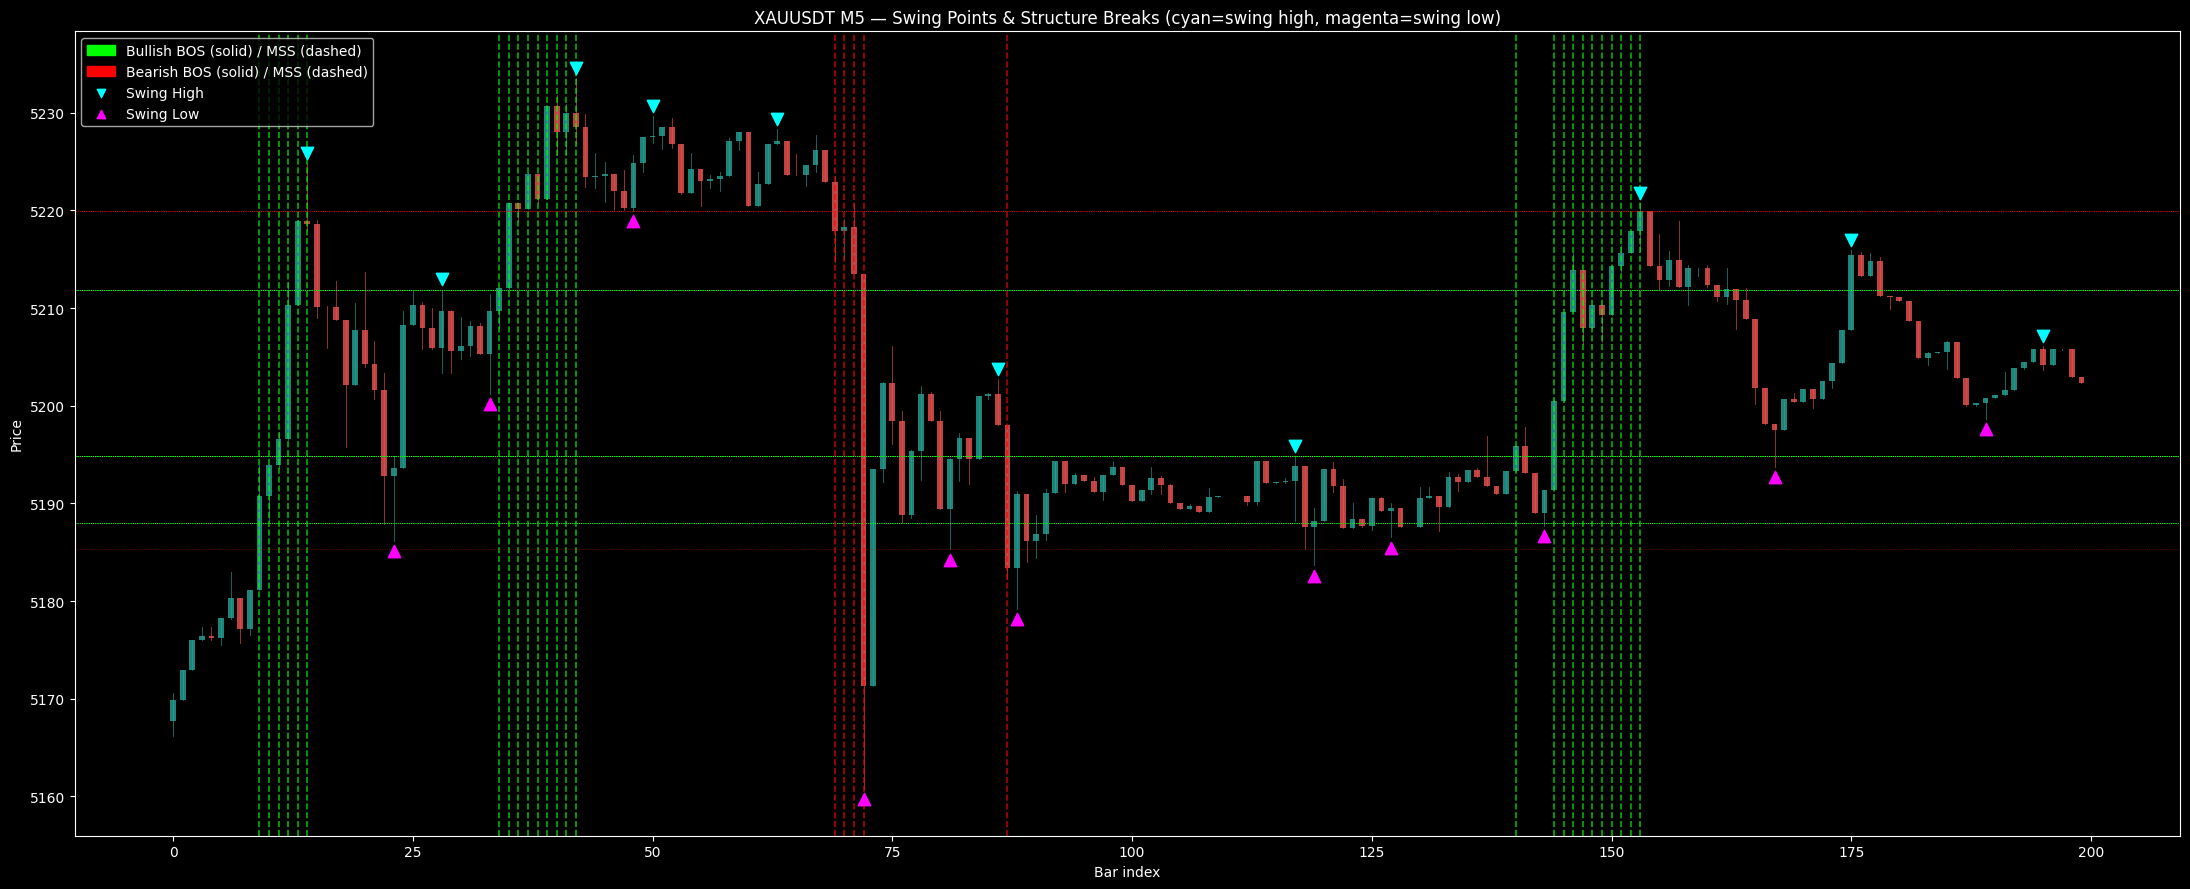

In [3]:
# ── Visualize swing points + BOS on chart ──────────────────────────────────
start, end = 400, 600
chart = m5.iloc[start:end]
chart_swings = [s for s in swings if start <= s.bar_idx < end]
chart_breaks = [b for b in breaks if start <= b.break_bar_idx < end]

fig, ax = plt.subplots(figsize=(22, 9))

for i, (ts, row) in enumerate(chart.iterrows()):
    color = '#26a69a' if row['close'] >= row['open'] else '#ef5350'
    local = i
    ax.plot([local, local], [row['low'], row['high']], color=color, linewidth=0.6, alpha=0.7)
    ax.bar(local, abs(row['close']-row['open']), bottom=min(row['open'],row['close']),
           color=color, width=0.6, alpha=0.8)

# Plot swing highs and lows
for s in chart_swings:
    local_i = s.bar_idx - start
    color   = 'cyan'   if s.kind == 'high' else 'magenta'
    marker  = 'v' if s.kind == 'high' else '^'
    ypos    = s.price * 1.0002 if s.kind == 'high' else s.price * 0.9998
    ax.scatter(local_i, ypos, color=color, marker=marker, s=80, zorder=5)

# Plot BOS/MSS levels
for b in chart_breaks:
    local_i = b.break_bar_idx - start
    color   = 'lime' if b.direction == 'bullish' else 'red'
    style   = 'solid' if not b.is_mss else 'dashed'
    label   = f'{"MSS" if b.is_mss else "BOS"} {b.direction}'
    ax.axvline(local_i, color=color, linewidth=1.2, linestyle=style, alpha=0.7)
    ax.axhline(b.swing_level, color=color, linewidth=0.6, linestyle=':', alpha=0.5)

ax.set_title(f'{SYMBOL} M5 — Swing Points & Structure Breaks (cyan=swing high, magenta=swing low)')
ax.set_xlabel('Bar index')
ax.set_ylabel('Price')

handles = [
    mpatches.Patch(color='lime', label='Bullish BOS (solid) / MSS (dashed)'),
    mpatches.Patch(color='red',  label='Bearish BOS (solid) / MSS (dashed)'),
    plt.scatter([], [], color='cyan',    marker='v', label='Swing High'),
    plt.scatter([], [], color='magenta', marker='^', label='Swing Low'),
]
ax.legend(handles=handles, loc='upper left')
plt.tight_layout()
plt.show()

In [4]:
# ── Compare OB signals: baseline vs BOS-required ──────────────────────────

cfg_baseline = OBSignalConfig(rr=2.0)
cfg_bos      = OBSignalConfig(rr=2.0, require_bos=True, bos_swing_len=5)

sigs_baseline = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_baseline)
sigs_bos      = list_ob_signals_enhanced(m5, risk_cash=RISK, config=cfg_bos)
sigs_bos_pass = get_passed_signals(sigs_bos)

print(f'Baseline signals: {len(sigs_baseline)}')
print(f'BOS signals (pass): {len(sigs_bos_pass)}')
pct = (1 - len(sigs_bos_pass)/max(len(sigs_baseline),1)) * 100
print(f'Reduction: {pct:.1f}% of signals filtered out')

print('\nRun notebook 12 for full A/B performance comparison with backtest metrics.')

Baseline signals: 290
BOS signals (pass): 179
Reduction: 38.3% of signals filtered out

Run notebook 12 for full A/B performance comparison with backtest metrics.
